# **Load CSV**

In [2]:
import pandas as pd
df = pd.read_csv(
    "train.csv",
    engine='python',
    quotechar='"',
    on_bad_lines='skip',
    encoding='utf-8'
)
df.head()


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [3]:
df.tail()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
30499,50f597c8edae427c,"No, from what I've seen on Wikipedia, that won...",0,0,0,0,0,0
30500,50f59d41b91ef948,"""\n\n International Burn a Koran Day \n\nclear...",0,0,0,0,0,0
30501,50f608eebef7f8b4,"""\nI disagree. The article and its references...",0,0,0,0,0,0
30502,50f618afefc3a985,"""\nWithin your post lies the problem, Vorangor...",0,0,0,0,0,0
30503,50f66e3ec150b300,"Lord knows I have tried, Blake. \n\nHe edits f...",0,0,0,0,0,0


In [4]:
df.shape

(30504, 8)

In [5]:
df.describe()


,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,30504.000000,30504.000000,30504.000000,30504.000000,30504.000000,30504.000000
mean,0.098512,0.010556,0.053239,0.003278,0.050223,0.008917
std,0.298010,0.102200,0.224513,0.057163,0.218408,0.094009
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30504 entries, 0 to 30503
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             30504 non-null  object
 1   comment_text   30504 non-null  object
 2   toxic          30504 non-null  int64 
 3   severe_toxic   30504 non-null  int64 
 4   obscene        30504 non-null  int64 
 5   threat         30504 non-null  int64 
 6   insult         30504 non-null  int64 
 7   identity_hate  30504 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 1.9+ MB


In [7]:
df.isnull().sum()


,0
id,0
comment_text,0
toxic,0
severe_toxic,0
obscene,0
threat,0
insult,0
identity_hate,0


In [8]:
labeled_columns = df.iloc[:, 2:].sum()
labeled_columns

,0
toxic,3005
severe_toxic,322
obscene,1624
threat,100
insult,1532
identity_hate,272


In [9]:
toxic_columns = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']
df['num_labels'] = df[toxic_columns].sum(axis=1)
df['num_labels']

,num_labels
0,0
1,0
2,0
3,0
4,0
...,...
30499,0
30500,0
30501,0
30502,0


In [10]:
rowsums = df['num_labels']

no_label_count = 0

for count in rowsums:
    if count == 0:
        no_label_count += 1

print("Total number of comments:", len(df))
print("Total number of comments without labels:", no_label_count)
print("Total labels:", rowsums.sum())

Total number of comments: 30504
Total number of comments without labels: 27321
Total labels: 6855


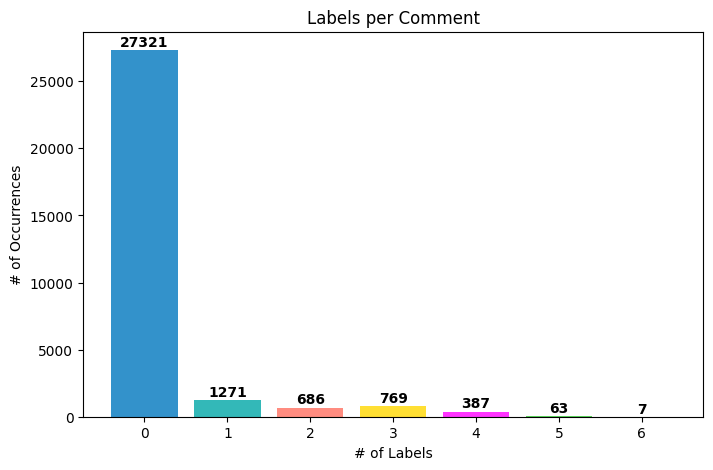

In [11]:
import matplotlib.pyplot as plt

label_counts = rowsums.value_counts().sort_index()

colors = ['#0077BE', '#00A6A6', '#FF6F61', '#FFD700', '#FF00FF', '#32CD32', '#1E3A8A']

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(label_counts.index.astype(str), label_counts.values, color=colors[:len(label_counts)], alpha=0.8)

plt.title('Labels per Comment')
plt.ylabel('# of Occurrences')
plt.xlabel('# of Labels')

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + max(label_counts.values)*0.01,
        str(height),
        ha='center',
        fontweight='bold'
    )

plt.show()

# **Toxic Comment Label Counts Graph**

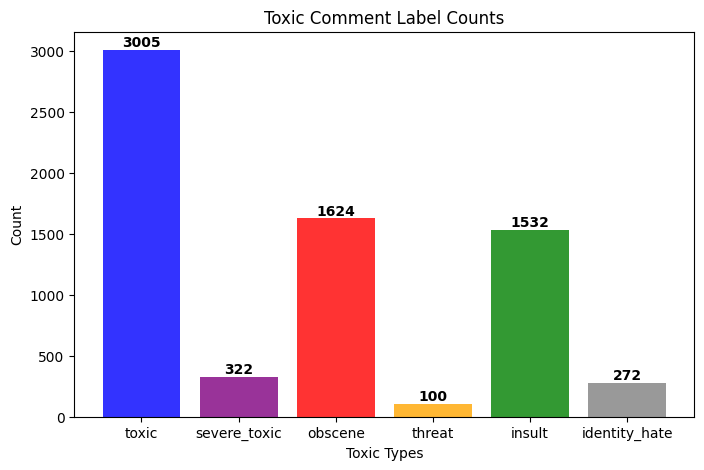

In [12]:
import matplotlib.pyplot as plt


# Count of each label
x = df[toxic_columns].sum()

# Colors: blue, purple, red, orange, green, grey
colors = ['blue', 'purple', 'red', 'orange', 'green', 'grey']

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(x.index, x.values, color=colors, alpha=0.8)

plt.title('Toxic Comment Label Counts')
plt.ylabel('Count')
plt.xlabel('Toxic Types')

# Add value labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(x.values)*0.01, str(height),
             ha='center', fontweight='bold')

plt.show()

# **Drop the missing value**

In [13]:
df = df.drop(columns=['id'], axis=1)
df.head()

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,num_labels
0,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,0
1,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,0
2,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,0
3,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,0
4,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,0


# **Fill with default value 0**

In [15]:
df.fillna({
    'comment_text': 'no comment',
    'toxic': 0,
    'severe_toxic': 0,
    'obscene': 0,
    'threat': 0,
    'insult': 0,
    'identity_hate': 0
})

df.head()

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,num_labels
0,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,0
1,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,0
2,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,0
3,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,0
4,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,0


# **Remove Stopwords**

In [16]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords


stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    no_stopword_text = [w for w in text.split() if not w in stop_words]
    return " ".join(no_stopword_text)

df['comment_removed_stopword'] = df['comment_text'].apply(remove_stopwords)
df[['comment_text', 'comment_removed_stopword']].head(5)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,comment_text,comment_removed_stopword
0,Explanation\nWhy the edits made under my usern...,Explanation Why edits made username Hardcore M...
1,D'aww! He matches this background colour I'm s...,D'aww! He matches background colour I'm seemin...
2,"Hey man, I'm really not trying to edit war. It...","Hey man, I'm really trying edit war. It's guy ..."
3,"""\nMore\nI can't make any real suggestions on ...",""" More I can't make real suggestions improveme..."
4,"You, sir, are my hero. Any chance you remember...","You, sir, hero. Any chance remember page that'..."


# **Remove contractions**

In [17]:
import re

def clean_text(text):

    text = str(text).lower()

    #  text preprocessing for contractions
    text = re.sub(r"what's", "what is", text)
    text = re.sub(r"he's", "he is", text)
    text = re.sub(r"she's", "she is", text)
    text = re.sub(r"it's", "it is", text)
    text = re.sub(r"that's", "that is", text)
    text = re.sub(r"where's", "where is", text)
    text = re.sub(r"how's", "how is", text)

    text = re.sub(r"\'ve", " have", text)
    text = re.sub(r"\'re", " are", text)
    text = re.sub(r"\'d", " would", text)
    text = re.sub(r"\'ll", " will", text)

    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"can't", "cannot", text)
    text = re.sub(r"n't", " not", text)

    text = re.sub(r"i'm", "i am", text)
    text = re.sub(r"'bout", "about", text)
    text = re.sub(r"'til", "until", text)

    text = re.sub(r"[^a-zA-Z]", " ", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

df['comment_cleaned'] = df['comment_text'].apply(clean_text)
df[['comment_text', 'comment_cleaned']].head(5)


,comment_text,comment_cleaned
0,Explanation\nWhy the edits made under my usern...,explanation why the edits made under my userna...
1,D'aww! He matches this background colour I'm s...,d aww he matches this background colour i am s...
2,"Hey man, I'm really not trying to edit war. It...",hey man i am really not trying to edit war it ...
3,"""\nMore\nI can't make any real suggestions on ...",more i cannot make any real suggestions on imp...
4,"You, sir, are my hero. Any chance you remember...",you sir are my hero any chance you remember wh...


# **Apply Stemmer**

In [18]:
from nltk.stem import SnowballStemmer

stemmer = SnowballStemmer("english")

def stemming(sentence):
    words = sentence.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    return " ".join(stemmed_words)

df['comment_stemmed'] = df['comment_text'].apply(stemming)
df[['comment_text', 'comment_stemmed']].head(5)

,comment_text,comment_stemmed
0,Explanation\nWhy the edits made under my usern...,explan whi the edit made under my usernam hard...
1,D'aww! He matches this background colour I'm s...,d'aww! he match this background colour i'm see...
2,"Hey man, I'm really not trying to edit war. It...","hey man, i'm realli not tri to edit war. it ju..."
3,"""\nMore\nI can't make any real suggestions on ...",""" more i can't make ani real suggest on improv..."
4,"You, sir, are my hero. Any chance you remember...","you, sir, are my hero. ani chanc you rememb wh..."


# **Apply all cleaning process to raw text**

In [19]:
def preprocess_text(text):


    cleaned = clean_text(text)
    no_stop = remove_stopwords(cleaned)
    stemmed = stemming(no_stop)

    return stemmed

df['comment_processed'] = df['comment_text'].apply(preprocess_text)
df[['comment_text', 'comment_processed']].head(5)

,comment_text,comment_processed
0,Explanation\nWhy the edits made under my usern...,explan edit made usernam hardcor metallica fan...
1,D'aww! He matches this background colour I'm s...,aww match background colour seem stuck thank t...
2,"Hey man, I'm really not trying to edit war. It...",hey man realli tri edit war guy constant remov...
3,"""\nMore\nI can't make any real suggestions on ...",cannot make real suggest improv wonder section...
4,"You, sir, are my hero. Any chance you remember...",sir hero chanc rememb page


In [20]:
df.head(5)

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,num_labels,comment_removed_stopword,comment_cleaned,comment_stemmed,comment_processed
0,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,0,Explanation Why edits made username Hardcore M...,explanation why the edits made under my userna...,explan whi the edit made under my usernam hard...,explan edit made usernam hardcor metallica fan...
1,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,0,D'aww! He matches background colour I'm seemin...,d aww he matches this background colour i am s...,d'aww! he match this background colour i'm see...,aww match background colour seem stuck thank t...
2,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,0,"Hey man, I'm really trying edit war. It's guy ...",hey man i am really not trying to edit war it ...,"hey man, i'm realli not tri to edit war. it ju...",hey man realli tri edit war guy constant remov...
3,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,0,""" More I can't make real suggestions improveme...",more i cannot make any real suggestions on imp...,""" more i can't make ani real suggest on improv...",cannot make real suggest improv wonder section...
4,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,0,"You, sir, hero. Any chance remember page that'...",you sir are my hero any chance you remember wh...,"you, sir, are my hero. ani chanc you rememb wh...",sir hero chanc rememb page


In [21]:
!pip install --upgrade gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 54.4 MB/s eta 0:00:00


# **Load FastText**

In [22]:

import gensim.downloader as api
word_vectors = api.load("fasttext-wiki-news-subwords-300")


[==================================================] 100.0% 958.5/958.4MB downloaded


# **pooling feautures to combine fixed sized vector**

In [24]:
import numpy as np

import numpy as np

def get_embedding_features(text):

    words = text.split()
    embeddings = []

    for w in words:
        try:
            embeddings.append(word_vectors.get_vector(w))
        except KeyError:
            continue

    if not embeddings:
        return {
            "mean": np.zeros(300),
            "max": np.zeros(300),
            "min": np.zeros(300),
        }

    embeddings = np.array(embeddings)
    return {
        "mean": np.mean(embeddings, axis=0),
        "max": np.max(embeddings, axis=0),
        "min": np.min(embeddings, axis=0)
    }

In [26]:

features_list = [get_embedding_features(c) for c in df['comment_processed']]

X_dict = {
    "mean": np.array([f["mean"] for f in features_list]),
    "max": np.array([f["max"] for f in features_list]),
    "min": np.array([f["min"] for f in features_list]),
}

y = df[toxic_columns].values




# **KNN Model Train**

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import StandardScaler

knn = KNeighborsClassifier(n_neighbors=5)

trained_knn_models = {}
trained_models = {}
model_name = "KNN"

for feature_name, X_feature in X_dict.items():
    print(f"\n--- Training KNN - {feature_name} ---")

    X_train, X_test, y_train, y_test = train_test_split(
        X_feature, y, test_size=0.2, random_state=42
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = MultiOutputClassifier(knn)
    model.fit(X_train, y_train)
    print(f"\n---  Training KNN done with- {feature_name} ---")
    trained_knn_models[feature_name] = (model, X_test, y_test)

    # Initialize the inner dictionary
    if feature_name not in trained_models:
        trained_models[feature_name] = {}
    trained_models[feature_name][model_name] = (model, scaler)


--- Training KNN - mean ---

---  Training KNN done with- mean ---

--- Training KNN - max ---

---  Training KNN done with- max ---

--- Training KNN - min ---

---  Training KNN done with- min ---


# **KNN accuracy and classificatin report**


In [28]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

evaluation_results = {}


for feature_name, (model, X_test, y_test) in trained_knn_models.items():
    print(f"\n--- Evaluation (KNN) - {feature_name} ---")

    # Predictions
    y_pred = model.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")

    # ROC AUC Score
    auc_score = roc_auc_score(y_test, y_pred)
    print(f"ROC AUC Score: {auc_score:.4f}")

    # Classification Report
    class_report = classification_report(
        y_test,
        y_pred,
        target_names=toxic_columns,
        zero_division=0
    )
    print("\nClassification Report:")
    print(class_report)

    # Save results
    evaluation_results[(feature_name, model_name)] = {
    "model": model,
    "accuracy": acc,
    "roc_auc": auc_score,
    "classification_report": class_report,
    "y_pred": y_pred,
    "y_test": y_test,
    "X_test": X_test
}


--- Evaluation (KNN) - mean ---
Accuracy: 0.8954
ROC AUC Score: 0.6701

Classification Report:
               precision    recall  f1-score   support

        toxic       0.78      0.53      0.63       614
 severe_toxic       0.24      0.16      0.19        73
      obscene       0.78      0.59      0.67       343
       threat       0.75      0.15      0.25        20
       insult       0.68      0.51      0.58       307
identity_hate       0.40      0.14      0.20        44

    micro avg       0.72      0.51      0.60      1401
    macro avg       0.60      0.35      0.42      1401
 weighted avg       0.72      0.51      0.59      1401
  samples avg       0.05      0.04      0.04      1401


--- Evaluation (KNN) - max ---
Accuracy: 0.8984
ROC AUC Score: 0.6031

Classification Report:
               precision    recall  f1-score   support

        toxic       0.85      0.33      0.48       614
 severe_toxic       0.36      0.07      0.11        73
      obscene       0.85      0.37 

# **Logistic Regression**

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import StandardScaler

lr = LogisticRegression(max_iter=500)

trained_lr_models = {}
model_name = "Logistic Regression"

for feature_name, X_feature in X_dict.items():

    print(f"\n---  Training Logistic Regression with- {feature_name} ---")

    X_train, X_test, y_train, y_test = train_test_split(
        X_feature, y, test_size=0.2, random_state=42
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = MultiOutputClassifier(lr)
    model.fit(X_train, y_train)


    print(f"\n---Logistic Regression Training Done with- {feature_name} ---")

    trained_lr_models[feature_name] = (model, X_test, y_test)
    trained_models[feature_name][model_name] = (model, scaler)


---  Training Logistic Regression with- mean ---

---Logistic Regression Training Done with- mean ---

---  Training Logistic Regression with- max ---

---Logistic Regression Training Done with- max ---

---  Training Logistic Regression with- min ---

---Logistic Regression Training Done with- min ---


# **Logistic Regression Accuracy and Classificatin Report**

In [31]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import numpy as np

for feature_name, (model, X_test, y_test) in trained_lr_models.items():
    print(f"\n--- Evaluation (Logistic Regression) - {feature_name} ---")

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    # If multi-class, select probability for positive class only
    if isinstance(y_prob, list):  # for multi-label, sklearn returns a list of arrays
        y_prob = np.column_stack([prob[:, 1] for prob in y_prob])
    else:  # binary classification
        y_prob = y_prob[:, 1] if y_prob.shape[1] == 2 else y_prob

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")

    # ROC AUC Score
    try:
        auc_score = roc_auc_score(y_test, y_prob, average="weighted")  # weighted better for multi-label
        print(f"ROC AUC Score: {auc_score:.4f}")
    except Exception as e:
        print(f"ROC AUC Error: {e}")
        auc_score = None

    # Classification Report (only overall metrics if desired)
    class_report = classification_report(
        y_test,
        y_pred,
        target_names=toxic_columns,
        zero_division=0
    )
    print("\nClassification Report:")
    print(class_report)

    # Save results
    evaluation_results[(feature_name, "Logistic Regression")] = {
        "model": model,
        "accuracy": acc,
        "roc_auc": auc_score,
        "classification_report": class_report,
        "y_pred": y_pred,
        "y_test": y_test,
        "X_test": X_test
    }


--- Evaluation (Logistic Regression) - mean ---
Accuracy: 0.8961
ROC AUC Score: 0.9562

Classification Report:
               precision    recall  f1-score   support

        toxic       0.80      0.60      0.68       614
 severe_toxic       0.27      0.18      0.21        73
      obscene       0.81      0.60      0.69       343
       threat       0.27      0.20      0.23        20
       insult       0.68      0.46      0.55       307
identity_hate       0.30      0.18      0.23        44

    micro avg       0.73      0.53      0.61      1401
    macro avg       0.52      0.37      0.43      1401
 weighted avg       0.72      0.53      0.61      1401
  samples avg       0.05      0.05      0.05      1401


--- Evaluation (Logistic Regression) - max ---
Accuracy: 0.8979
ROC AUC Score: 0.9369

Classification Report:
               precision    recall  f1-score   support

        toxic       0.79      0.56      0.66       614
 severe_toxic       0.42      0.26      0.32        73
   

# **Random Forest**

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import StandardScaler

rf = RandomForestClassifier(n_estimators=200)

trained_rf_models = {}
model_name = "Random Forest"

for feature_name, X_feature in X_dict.items():

    print(f"\n--- Training Random Forest - {feature_name} ---")

    X_train, X_test, y_train, y_test = train_test_split(
        X_feature, y, test_size=0.2, random_state=42
    )



    model = MultiOutputClassifier(rf)
    model.fit(X_train, y_train)

    print(f"\n---Random Forest Training Done with- {feature_name} ---")
    trained_rf_models[feature_name] = (model, X_test, y_test)
    trained_models[feature_name][model_name] = (model, None)



--- Training Random Forest - mean ---

---Random Forest Training Done with- mean ---

--- Training Random Forest - max ---

---Random Forest Training Done with- max ---

--- Training Random Forest - min ---

---Random Forest Training Done with- min ---


# **Random Forest Accuracy and Classificatin Matrix**

In [33]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

evaluation_results_rf = {}

for feature_name, (model, X_test, y_test) in trained_rf_models.items():
    print(f"\n--- Evaluation (Random Forest) - {feature_name} ---")

    # Predictions
    y_pred = model.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")

    # ROC AUC Score
    auc_score = roc_auc_score(y_test, y_pred)
    print(f"ROC AUC Score: {auc_score:.4f}")

    # Classification Report
    class_report = classification_report(
        y_test,
        y_pred,
        target_names=toxic_columns,
        zero_division=0
    )
    print("\nClassification Report:")
    print(class_report)

    # Save results
    evaluation_results[(feature_name, model_name)] = {
    "model": model,
    "accuracy": acc,
    "roc_auc": auc_score,
    "classification_report": class_report,
    "y_pred": y_pred,
    "y_test": y_test,
    "X_test": X_test
}


--- Evaluation (Random Forest) - mean ---
Accuracy: 0.9028
ROC AUC Score: 0.6161

Classification Report:
               precision    recall  f1-score   support

        toxic       0.94      0.41      0.57       614
 severe_toxic       0.43      0.12      0.19        73
      obscene       0.94      0.43      0.59       343
       threat       0.00      0.00      0.00        20
       insult       0.84      0.35      0.50       307
identity_hate       0.67      0.09      0.16        44

    micro avg       0.90      0.37      0.52      1401
    macro avg       0.64      0.23      0.33      1401
 weighted avg       0.87      0.37      0.52      1401
  samples avg       0.04      0.03      0.03      1401


--- Evaluation (Random Forest) - max ---
Accuracy: 0.9046
ROC AUC Score: 0.6368

Classification Report:
               precision    recall  f1-score   support

        toxic       0.92      0.38      0.54       614
 severe_toxic       0.27      0.05      0.09        73
      obscene  

# **Decision Tree**

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.multioutput import MultiOutputClassifier

dt = DecisionTreeClassifier(random_state=42)

trained_dt_models = {}
model_name="Decision Tree"

for feature_name, X_feature in X_dict.items():
    print(f"\n--- Training Decision Tree - {feature_name} ---")

    X_train, X_test, y_train, y_test = train_test_split(
        X_feature, y, test_size=0.2, random_state=42
    )
    model = MultiOutputClassifier(dt)
    model.fit(X_train, y_train)


    print(f"\n---Decision Tree training Done with- {feature_name} ---")
    trained_dt_models[feature_name] = (model, X_test, y_test)
    trained_models[feature_name][model_name] = (model, None)



--- Training Decision Tree - mean ---

---Decision Tree training Done with- mean ---

--- Training Decision Tree - max ---

---Decision Tree training Done with- max ---

--- Training Decision Tree - min ---

---Decision Tree training Done with- min ---


# **Decision Tree Accuracy and Classification Report**

In [35]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score


for feature_name, (model, X_test, y_test) in trained_dt_models.items():
    print(f"\n--- Evaluation (Decision Tree) - {feature_name} ---")

    # Predictions
    y_pred = model.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")

    # ROC AUC Score
    auc_score = roc_auc_score(y_test, y_pred)
    print(f"ROC AUC Score: {auc_score:.4f}")

    # Classification Report
    class_report = classification_report(
        y_test,
        y_pred,
        target_names=toxic_columns,
        zero_division=0
    )
    print("\nClassification Report:")
    print(class_report)


  # Save results
    evaluation_results[(feature_name, model_name)] = {
    "model": model,
    "accuracy": acc,
    "roc_auc": auc_score,
    "classification_report": class_report,
    "y_pred": y_pred,
    "y_test": y_test,
    "X_test": X_test
}


--- Evaluation (Decision Tree) - mean ---
Accuracy: 0.8027
ROC AUC Score: 0.6662

Classification Report:
               precision    recall  f1-score   support

        toxic       0.45      0.50      0.48       614
 severe_toxic       0.20      0.25      0.22        73
      obscene       0.44      0.53      0.48       343
       threat       0.11      0.15      0.13        20
       insult       0.38      0.49      0.43       307
identity_hate       0.13      0.25      0.17        44

    micro avg       0.40      0.48      0.44      1401
    macro avg       0.29      0.36      0.32      1401
 weighted avg       0.41      0.48      0.44      1401
  samples avg       0.05      0.04      0.04      1401


--- Evaluation (Decision Tree) - max ---
Accuracy: 0.8143
ROC AUC Score: 0.6853

Classification Report:
               precision    recall  f1-score   support

        toxic       0.47      0.51      0.49       614
 severe_toxic       0.27      0.33      0.30        73
      obscene  

# **Naive Bayes**

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.multioutput import MultiOutputClassifier

nb = GaussianNB()

trained_nb_models = {}
model_name = "Naive Bayes"

for feature_name, X_feature in X_dict.items():
    print(f"\n--- Training Naive Bayes - {feature_name} ---")

    X_train, X_test, y_train, y_test = train_test_split(
        X_feature, y, test_size=0.2, random_state=42
    )

    model = MultiOutputClassifier(nb)
    model.fit(X_train, y_train)

    print(f"\n---Naive Bayes Training Done with- {feature_name} ---")
    trained_nb_models[feature_name] = (model, X_test, y_test)
    trained_models[feature_name][model_name] = (model, None)



--- Training Naive Bayes - mean ---

---Naive Bayes Training Done with- mean ---

--- Training Naive Bayes - max ---

---Naive Bayes Training Done with- max ---

--- Training Naive Bayes - min ---

---Naive Bayes Training Done with- min ---


# **Naive Bayes Accuracy and Classification Report**

In [71]:
from sklearn.metrics import accuracy_score, classification_report

evaluation_results_nb = {}

for feature_name, (model, X_test, y_test) in trained_nb_models.items():
    print(f"\n--- Evaluation (Naive Bayes) - {feature_name} ---")

    # Predictions
    y_pred = model.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")

    # ROC AUC Score
    auc_score = roc_auc_score(y_test, y_pred)
    print(f"ROC AUC Score: {auc_score:.4f}")

    # Classification Report
    class_report = classification_report(
        y_test,
        y_pred,
        target_names=toxic_columns,
        zero_division=0
    )
    print("\nClassification Report:")
    print(class_report)

   # Save results
    evaluation_results[(feature_name, model_name)] = {
    "model": model,
    "accuracy": acc,
    "roc_auc": auc_score,
    "classification_report": class_report,
    "y_pred": y_pred,
    "y_test": y_test,
    "X_test": X_test
}


--- Evaluation (Naive Bayes) - mean ---
Accuracy: 0.7710
ROC AUC Score: 0.7761

Classification Report:
               precision    recall  f1-score   support

        toxic       0.31      0.56      0.39       614
 severe_toxic       0.08      0.71      0.15        73
      obscene       0.25      0.65      0.36       343
       threat       0.02      0.80      0.05        20
       insult       0.21      0.64      0.32       307
identity_hate       0.04      0.66      0.07        44

    micro avg       0.17      0.61      0.27      1401
    macro avg       0.15      0.67      0.22      1401
 weighted avg       0.25      0.61      0.34      1401
  samples avg       0.03      0.06      0.04      1401


--- Evaluation (Naive Bayes) - max ---
Accuracy: 0.6779
ROC AUC Score: 0.7602

Classification Report:
               precision    recall  f1-score   support

        toxic       0.21      0.56      0.30       614
 severe_toxic       0.05      0.60      0.09        73
      obscene      

# **Best feature per model**

In [38]:
# the best feature per model
best_feature_per_model = {}

for (feature_name, model_name), metrics in evaluation_results.items():
    metric = metrics["accuracy"]

    if model_name not in best_feature_per_model:
        best_feature_per_model[model_name] = {
            "feature": feature_name,
            "score": metric
        }
    else:
        if metric > best_feature_per_model[model_name]["score"]:
            best_feature_per_model[model_name] = {
                "feature": feature_name,
                "score": metric
            }

for model, info in best_feature_per_model.items():
    print(f"{model}: Best Feature = {info['feature']} (Score = {info['score']:.4f})")

KNN: Best Feature = min (Score = 0.8997)
Logistic Regression: Best Feature = min (Score = 0.8989)
Random Forest: Best Feature = min (Score = 0.9056)
Decision Tree: Best Feature = min (Score = 0.8264)
Naive Bayes: Best Feature = mean (Score = 0.7710)


# **ROC Curve: Best Feature per Model**

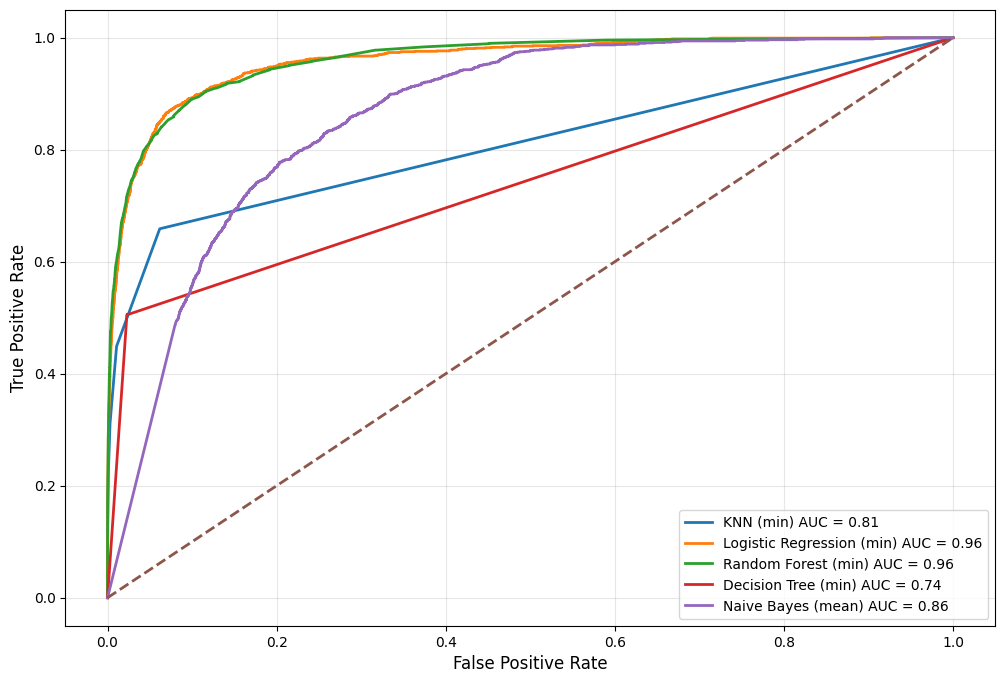

In [76]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np


plt.figure(figsize=(12, 8))

for model_name, info in best_feature_per_model.items():
    feature_name = info["feature"]
    model = evaluation_results[(feature_name, model_name)]["model"]
    X_test = evaluation_results[(feature_name, model_name)]["X_test"]
    y_test = evaluation_results[(feature_name, model_name)]["y_test"]

    # Get predicted probabilities
    if hasattr(model, "predict_proba"):
        if hasattr(model, "estimators_"):
            y_prob_list = []
            for estimator in model.estimators_:
                y_prob_list.append(estimator.predict_proba(X_test)[:, 1])
            y_pred_prob = np.array(y_prob_list).T
        else:
            y_pred_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_pred_prob = model.predict(X_test)


    if len(y_test.shape) > 1 and y_test.shape[1] > 1:
        y_test_bin = y_test
    else:
        y_test_bin = label_binarize(y_test, classes=np.unique(y_test))

    # ROC calculation
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_pred_prob.ravel())
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} ({feature_name}) AUC = {roc_auc:.2f}')


plt.plot([0, 1], [0, 1], linestyle='--', lw=2)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curves — Best feature per model)', fontsize=15)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)


plt.savefig("roc_curve.png", dpi=300, bbox_inches='tight')
plt.savefig("roc_curve.svg", bbox_inches='tight')

plt.show()
#

In [77]:
from google.colab import files
files.download("roc_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Best feature best model**

In [45]:
# Initialize
best_model = None
best_feature = None
best_score = -1

# best features per model
for model_name, info in best_feature_per_model.items():

      if info["score"] > best_score:
        best_score = info["score"]
        best_model = model_name
        best_feature = info["feature"]

print(f"Best Model: {best_model}")
print(f"Best Feature: {best_feature}")
print(f"Accuracy: {best_score:.4f}")



Best Model: Random Forest
Best Feature: min
Accuracy: 0.9056


# **ROC Curve Random Forest Min Pooling**

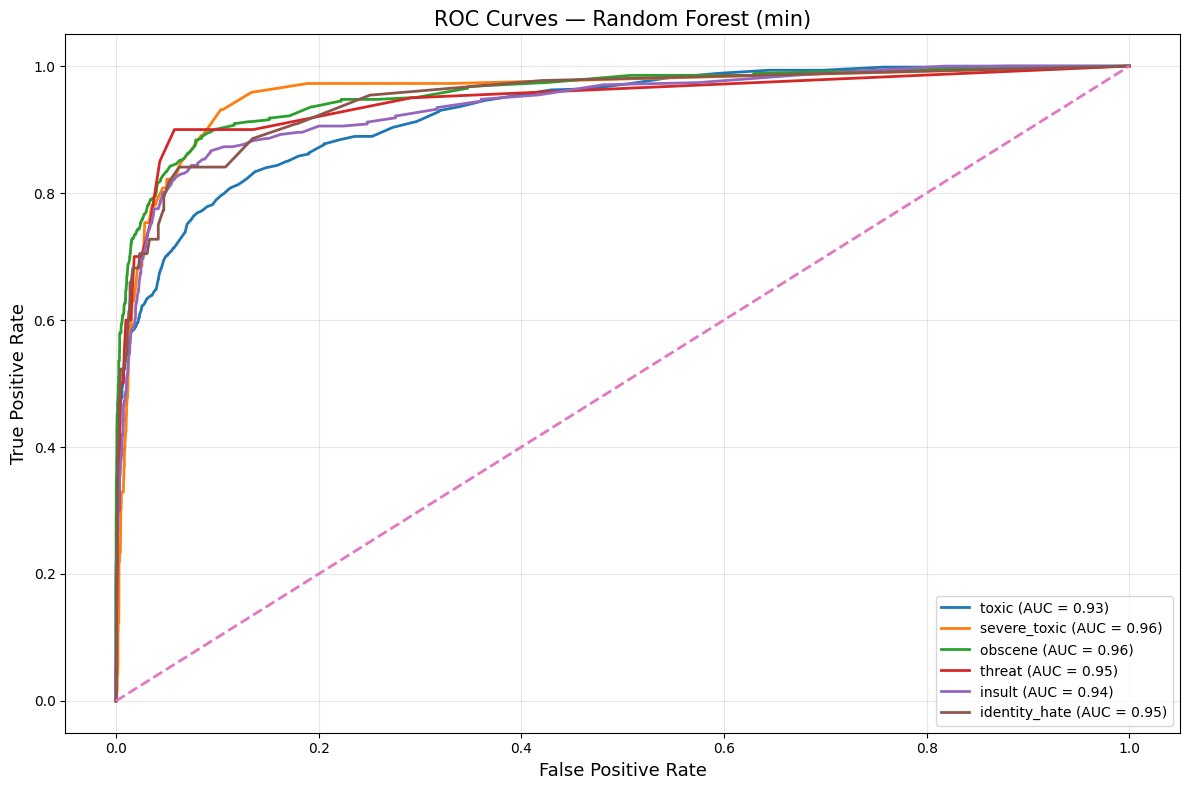

In [48]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

# Get best model info
best_result = evaluation_results[(best_feature, best_model)]
model = best_result["model"]
X_test = best_result["X_test"]
y_test = best_result["y_test"]

# Predicted probabilities
if hasattr(model, "predict_proba"):
    y_prob_list = model.predict_proba(X_test)

    if isinstance(y_prob_list, list):
        y_prob = np.column_stack([p[:, 1] for p in y_prob_list])
    else:
        y_prob = y_prob_list[:, 1]
else:
    y_prob = model.predict(X_test)


plt.figure(figsize=(12, 8))

n_labels = y_test.shape[1]

for i in range(n_labels):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr, tpr, lw=2,
        label=f'{toxic_columns[i]} (AUC = {roc_auc:.2f})'
    )


plt.plot([0, 1], [0, 1], linestyle='--', lw=2)

plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title(f'ROC Curves — {best_model} ({best_feature})', fontsize=15)

plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("roc_best_model.png", dpi=300, bbox_inches='tight')
plt.savefig("roc_best_model.svg", bbox_inches='tight')  # best quality

plt.show()

In [49]:
from google.colab import files
files.download("roc_best_model.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

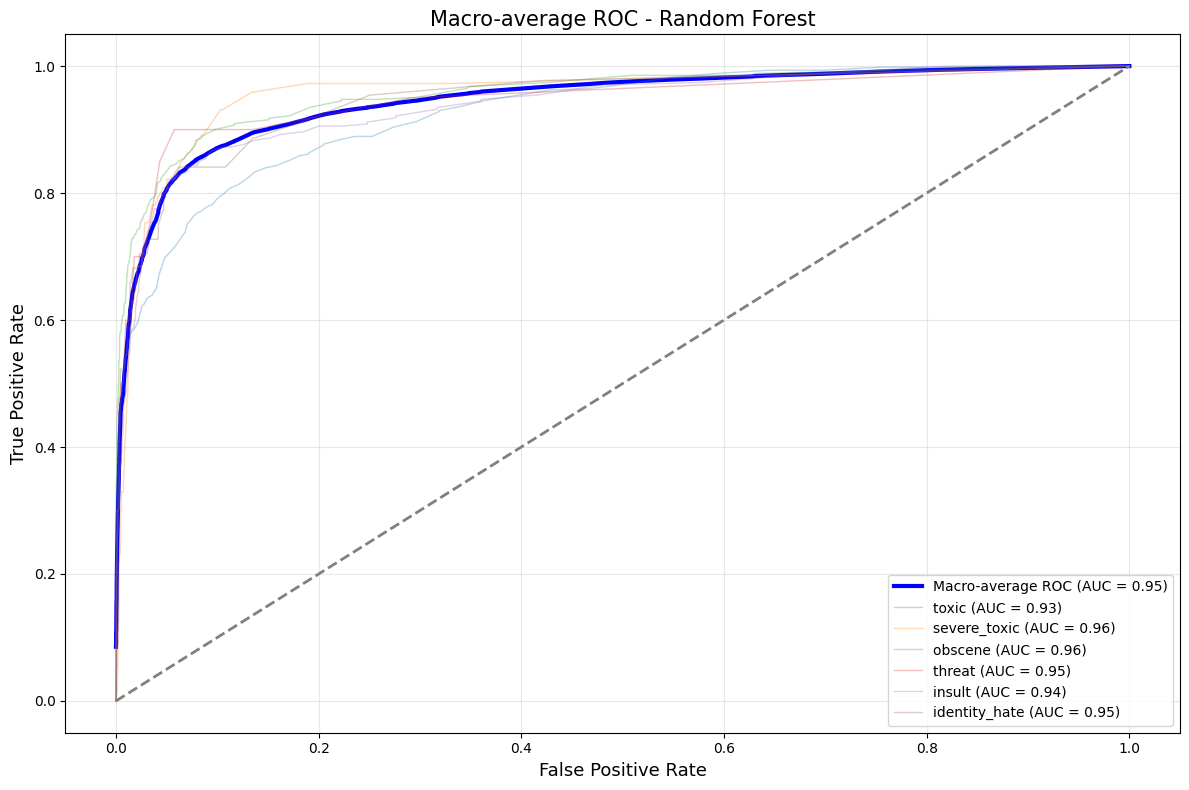

In [52]:
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# Predicted probabilities
if hasattr(model, "predict_proba"):
    y_prob_list = model.predict_proba(X_test)
    if isinstance(y_prob_list, list):
        y_prob = np.column_stack([p[:, 1] for p in y_prob_list])
    else:
        y_prob = y_prob_list[:, 1]
else:
    y_prob = model.predict(X_test)

n_labels = y_test.shape[1]

# Compute ROC for each label
fpr_dict = {}
tpr_dict = {}
roc_auc_dict = []

for i in range(n_labels):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_prob[:, i])
    fpr_dict[i] = fpr
    tpr_dict[i] = tpr
    roc_auc_dict.append(auc(fpr, tpr))

# Macro-average: interpolate all ROC curves
all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(n_labels)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_labels):
    mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
mean_tpr /= n_labels

macro_auc = auc(all_fpr, mean_tpr)

plt.figure(figsize=(12, 8))

plt.plot(
    all_fpr, mean_tpr, color='blue', lw=3,
    label=f'Macro-average ROC (AUC = {macro_auc:.2f})'
)


for i in range(n_labels):
    plt.plot(fpr_dict[i], tpr_dict[i], lw=1, alpha=0.3, label=f'{toxic_columns[i]} (AUC = {roc_auc_dict[i]:.2f})')


plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='gray')

plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title(f'Macro-average ROC - {best_model}', fontsize=15)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()


plt.savefig("macro_roc_best_model.png", dpi=300, bbox_inches='tight')
plt.savefig("macro_roc_best_model.svg", bbox_inches='tight')  # perfect scaling

plt.show()

In [53]:
from google.colab import files
files.download("macro_roc_best_model.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Confusion matrix - Random Forest Min Pooling (All Category)**

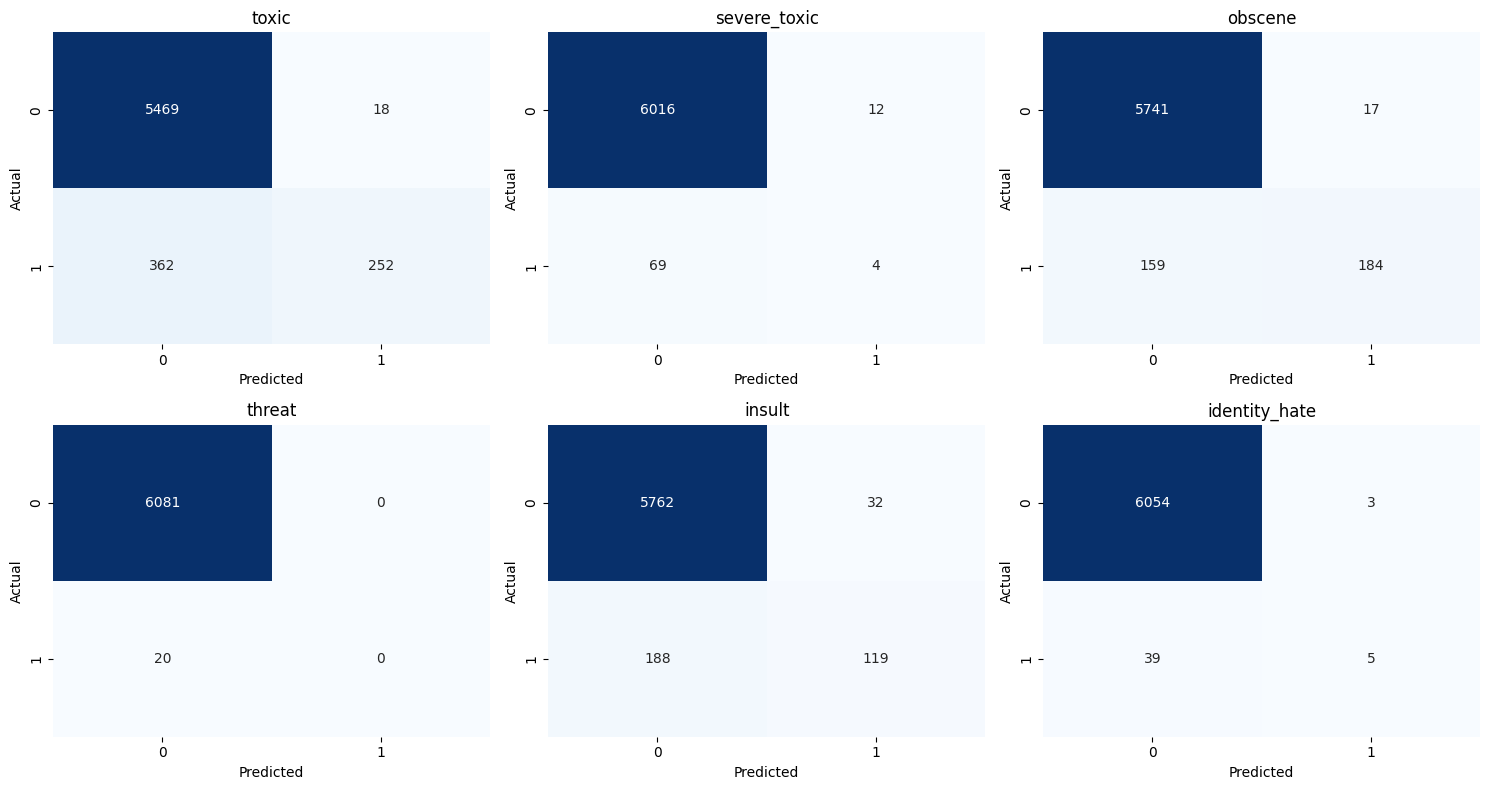

In [54]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions
y_pred = model.predict(X_test)

n_labels = y_test.shape[1]
cols = 3
rows = (n_labels + cols - 1) // cols

plt.figure(figsize=(cols * 5, rows * 4))

for i in range(n_labels):
    cm = confusion_matrix(y_test[:, i], y_pred[:, i])
    plt.subplot(rows, cols, i + 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{toxic_columns[i]}')

plt.tight_layout()
plt.show()

# **Confusion matrix - Random Forest Min Pooling**

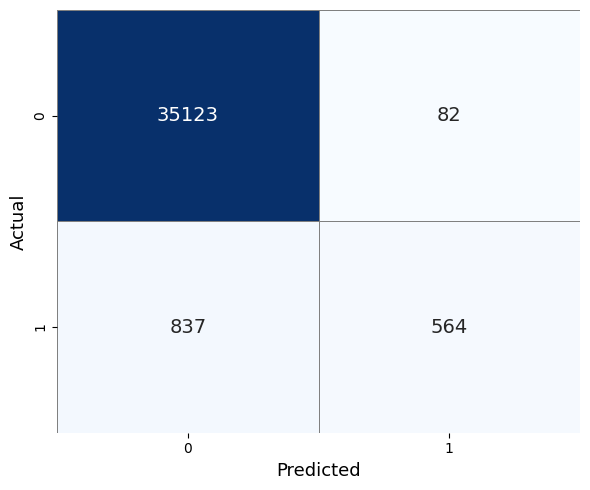

In [55]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get predictions
y_pred = model.predict(X_test)
n_labels = y_test.shape[1]


overall_cm = np.zeros((2, 2), dtype=int)

for i in range(n_labels):
    cm = confusion_matrix(y_test[:, i], y_pred[:, i])
    overall_cm += cm

plt.figure(figsize=(6,5))

sns.heatmap(
    overall_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    linewidths=0.5,
    linecolor='gray',
    annot_kws={"size": 14}
)


plt.xlabel('Predicted', fontsize=13)
plt.ylabel('Actual', fontsize=13)

plt.tight_layout()


plt.savefig("overall_confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.savefig("overall_confusion_matrix.svg", bbox_inches='tight')

plt.show()

In [56]:
from google.colab import files
files.download("overall_confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Predicted vs True Correlations**

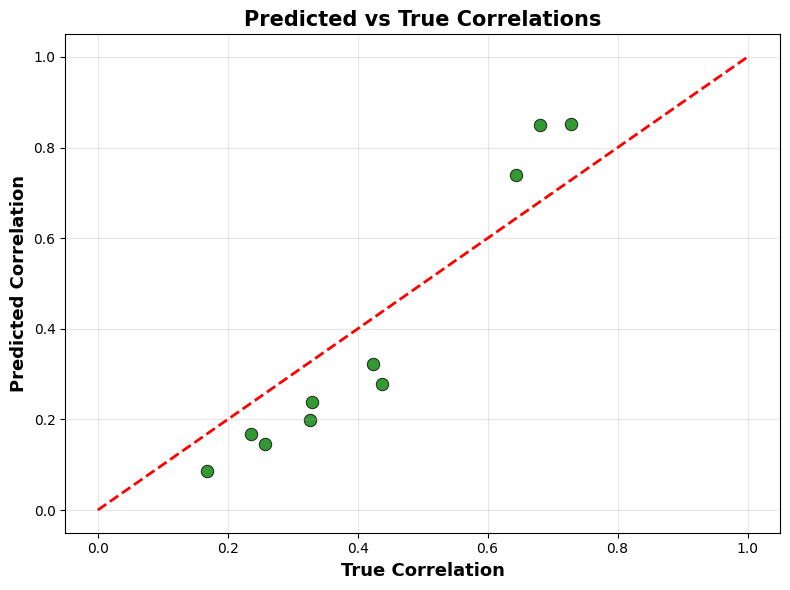

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns


# Convert y_test and predictions to DataFrames
y_true_df = pd.DataFrame(y_test, columns=toxic_columns)
y_pred = model.predict(X_test)
y_pred_df = pd.DataFrame(y_pred, columns=toxic_columns)

# Compute correlation matrices
true_corr = y_true_df.corr(method='pearson')
pred_corr = y_pred_df.corr(method='pearson')

# Flatten upper triangle for scatter plot
true_vals = true_corr.where(np.triu(np.ones(true_corr.shape), k=1).astype(bool)).stack()
pred_vals = pred_corr.where(np.triu(np.ones(pred_corr.shape), k=1).astype(bool)).stack()


plt.figure(figsize=(8, 6))

# Scatter plot: Predicted vs True Correlations
sns.scatterplot(
    x=true_vals,
    y=pred_vals,
    color='green',
    s=80,
    edgecolor='black',
    alpha=0.8
)

# Perfect correlation line
plt.plot([0, 1], [0, 1], 'r--', lw=2)


plt.xlabel("True Correlation", fontsize=13, fontweight='bold')
plt.ylabel("Predicted Correlation", fontsize=13, fontweight='bold')
plt.ylabel("Predicted Correlation", fontsize=13, fontweight='bold')
plt.title("Predicted vs True Correlations", fontsize=15, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()


plt.savefig("predicted_vs_true_scatter.png", dpi=300, bbox_inches='tight')
plt.savefig("predicted_vs_true_scatter.svg", bbox_inches='tight')

plt.show()

In [64]:
from google.colab import files
files.download("predicted_vs_true_scatter.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Predict comment method**

In [65]:
import numpy as np

def predict_best(comment, threshold=0.35):
    print("Input:", comment)

    # Step 1: Feature extraction
    vector = get_embedding_features(comment)

    # Step 2: Load best model + scaler
    model, scaler = trained_models[best_feature][best_model]

    # Step 3: Prepare input
    X = vector[best_feature].reshape(1, -1)

    if scaler is not None:
        X = scaler.transform(X)

    predicted_labels = []


    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X)


        if isinstance(probs, list):
            for i, prob_array in enumerate(probs):
                prob = prob_array[0][1]  # class 1 probability
                print(f"{toxic_columns[i]}: {prob:.3f}")

                if prob > threshold:
                    predicted_labels.append(toxic_columns[i])


        else:
            for i in range(len(toxic_columns)):
                prob = probs[0][i]
                print(f"{toxic_columns[i]}: {prob:.3f}")

                if prob > threshold:
                    predicted_labels.append(toxic_columns[i])

    else:
        print("Model does not support predict_proba, using predict()")

        pred = model.predict(X)

        # Ensure shape consistency
        pred = np.array(pred)

        if pred.ndim == 1:
            pred = pred.reshape(1, -1)

        for i in range(len(toxic_columns)):
            if pred[0][i] == 1:
                predicted_labels.append(toxic_columns[i])

    # Step 5: Final output
    if predicted_labels:
        print("Prediction:", ", ".join(predicted_labels))
    else:
        print("Prediction: no label")

# **Input and Output**

In [ ]:
text = input("Enter a comment: ")
predict_best(text)

In [ ]:
import joblib

model_object = evaluation_results[(best_feature, best_model)]["model"]

# Save trained models and metadata
joblib.dump(trained_models, "trained_models.pkl")
joblib.dump(best_feature, "best_feature.pkl")
joblib.dump(best_model, "best_model_name.pkl")

print(f"Saved {best_model} ({best_feature}) as best_model.pkl")

Saved Random Forest (min) as best_model.pkl


In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 34.1 MB/s eta 0:00:00


In [1]:
%%writefile app.py

import streamlit as st
import numpy as np
import joblib
import gensim.downloader as api


# Load trained models

trained_models = joblib.load("trained_models.pkl")
best_feature = joblib.load("best_feature.pkl")
best_model = joblib.load("best_model_name.pkl")

toxic_columns = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

category_colors = {
    "toxic": "#FF6666",
    "severe_toxic": "#990000",
    "obscene": "#FF33CC",
    "threat": "#FF9933",
    "insult": "#3399FF",
    "identity_hate": "#33CC99"
}

category_emojis = {
    "toxic": "😡",
    "severe_toxic": "💀",
    "obscene": "🤬",
    "threat": "⚠️",
    "insult": "😢",
    "identity_hate": "🚫"
}

# Load embeddings

@st.cache_resource
def load_embeddings():
    return api.load("fasttext-wiki-news-subwords-300")

word_vectors = load_embeddings()


# Toxic word list

toxic_word_list = set([
    "stupid", "idiot", "hate", "kill", "dumb", "fool", "trash", "ugly", "bastard", "loser"
])


# Feature extraction

def get_embedding_features(text):
    words = text.split()

    vectors = [
        word_vectors[w] if w in word_vectors else np.zeros(word_vectors.vector_size)
        for w in words
    ]

    if len(vectors) == 0:
        vectors = [np.zeros(word_vectors.vector_size)]

    vectors = np.array(vectors)

    return {
        "min": np.min(vectors, axis=0),
        "mean": np.mean(vectors, axis=0),
        "max": np.max(vectors, axis=0),
        "combined": np.concatenate([
            np.min(vectors, axis=0),
            np.mean(vectors, axis=0),
            np.max(vectors, axis=0)
        ])
    }, words


# Prediction function

def predict_best(comment, threshold=0.35):

    features, words = get_embedding_features(comment)

    model, scaler = trained_models[best_feature][best_model]

    X = features[best_feature].reshape(1, -1)

    if scaler is not None:
        X = scaler.transform(X)

    predicted_labels = []


    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X)

        # MultiOutputClassifier
        if isinstance(probs, list):
            for i, prob_array in enumerate(probs):
                prob = prob_array[0][1]
                if prob > threshold:
                    predicted_labels.append(toxic_columns[i])

        # Single classifier
        else:
            for i in range(len(toxic_columns)):
                prob = probs[0][i]
                if prob > threshold:
                    predicted_labels.append(toxic_columns[i])

    else:
        pred = model.predict(X)
        pred = np.array(pred)

        if pred.ndim == 1:
            pred = pred.reshape(1, -1)

        predicted_labels = [
            toxic_columns[i]
            for i in range(len(toxic_columns))
            if pred[0][i] == 1
        ]

    # Toxic words detection
    toxic_words = [w for w in words if w.lower() in toxic_word_list]

    return comment, predicted_labels, toxic_words


# Streamlit UI

st.set_page_config(page_title="💬 Toxic Comment Classifier", layout="centered")

st.title("💬 Toxic Comment Classifier")
st.markdown("A simple tool to detect toxic comments")
st.write("Enter a comment below and click **Classify**")

if 'comment' not in st.session_state:
    st.session_state.comment = ""

st.text_area("Enter your comment:", height=150, key='comment')

if st.button("⚡ Classify"):
    if st.session_state.comment.strip():
        result = predict_best(st.session_state.comment)
        st.session_state.result = result
    else:
        st.warning("Please enter a comment!")

if 'result' in st.session_state and st.session_state.result:
    comment, labels, toxic_words = st.session_state.result

    col1, col2 = st.columns(2)

    with col1:
        st.subheader("🏷️ Predicted Categories")

        if labels:
            html_labels = " ".join([
                f"<span style='color:white;background-color:{category_colors[label]}; "
                f"padding:6px 12px; border-radius:8px; margin:4px;'>"
                f"{category_emojis[label]} {label}</span>"
                for label in labels
            ])
            st.markdown(html_labels, unsafe_allow_html=True)
        else:
            st.success("✅ No toxic label detected!")

    with col2:
        st.subheader("✍️ Toxic Words in Comment")

        if toxic_words:
            highlighted_words = " ".join([
                f"<span style='background-color:#FF6666;color:white;"
                f"padding:2px 4px;border-radius:4px;'>{w}</span>"
                for w in toxic_words
            ])
            st.markdown(highlighted_words, unsafe_allow_html=True)
        else:
            st.write("No toxic words detected.")

Writing app.py


In [ ]:
!pip install pyngrok

In [ ]:
from pyngrok import ngrok

!ngrok authtoken 3C0NUW3SXeBRTEEdi2rbw1keV7x_78pH1oYL72JxMBjsAZs9X

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
from pyngrok import ngrok

ngrok.kill()
get_ipython().system_raw("streamlit run app.py --server.port 8501 &")

public_url = ngrok.connect(addr=8501, proto="http")
print("🚀 Streamlit app live at:", public_url)

🚀 Streamlit app live at: NgrokTunnel: "https://beaconless-tambra-interpervasively.ngrok-free.dev" -> "http://localhost:8501"
